# LV Ablations Notebook

This notebook is the notebook version of the Lotka--Volterra ablation plots, adapted to this repo layout. It reads saved ablation `.npz` files from `ablations/`, renders figures inline, and saves the main ablation figures to `figures/`.


In [90]:
from pathlib import Path
import re

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
ABLATIONS_DIR = ROOT / "ablations"
FIGURES_DIR = ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

STEP_OUTPUT = FIGURES_DIR / "lv_step_size_ablation.pdf"
DECAY_OUTPUT = FIGURES_DIR / "lv_decay_ablation.pdf"
MN_OUTPUT = FIGURES_DIR / "lv_mn_theta_error_boxplots.pdf"
LENGTHSCALE_OUTPUT = FIGURES_DIR / "lv_lengthscale_pair_ablation.pdf"

FIGSIZE = (6, 4)
SUMMARY_DPI = 150
TITLE_SIZE = 28
LABEL_SIZE = 26
TICK_SIZE = 22
LEGEND_SIZE = 20
LINE_WIDTH = 2.0
TITLE_PAD = 8
COLORS = {
    "gd": "#1b9e77",
    "pgd": "#d95f02",
}
BOX_COLORS = [
    "#4c78a8",
    "#e45756",
    "#72b7b2",
    "#b279a2",
    "#ff9da6",
    "#9d755d",
    "#bab0ab",
]

BASE_PLOT_RC = {
    "axes.grid": True,
    "font.family": "DejaVu Serif",
    "font.serif": ["Times New Roman"],
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath, amsfonts, mathrsfs, amssymb}",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.titlesize": TITLE_SIZE,
    "axes.labelsize": LABEL_SIZE,
    "legend.fontsize": LEGEND_SIZE,
    "legend.frameon": False,
    "xtick.labelsize": TICK_SIZE,
    "ytick.labelsize": TICK_SIZE,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "axes.linewidth": 1.2,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.minor.width": 1.0,
    "ytick.minor.width": 1.0,
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
    "lines.linewidth": LINE_WIDTH,
    "figure.figsize": FIGSIZE,
    "figure.dpi": 100,
}
LOCAL_PLOT_RC = dict(BASE_PLOT_RC)
plt.rcParams.update(BASE_PLOT_RC)


def _load_npz_dict(npz_path):
    npz_path = Path(npz_path)
    with np.load(npz_path) as data:
        return {key: data[key] for key in data.files}


def _save_figure(fig, output_path=None, **savefig_kwargs):
    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, **savefig_kwargs)
    return fig


def _make_single_color_boxplot(ax, series, labels, color, xlabel, ylabel, title=None, logy=True):
    bp = ax.boxplot(series, patch_artist=True, widths=0.6)
    palette = BOX_COLORS
    for idx, patch in enumerate(bp["boxes"]):
        patch.set_facecolor(palette[idx % len(palette)])
        patch.set_alpha(0.8)
    for median in bp["medians"]:
        median.set_color("black")
        median.set_linewidth(2.0)
    ax.set_xticks(np.arange(1, len(labels) + 1))
    ax.set_xticklabels(labels)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title is not None:
        ax.set_title(title, pad=TITLE_PAD)
    if logy:
        ax.set_yscale("log")
    return bp


def _theta_error_series_lv(npz_path):
    data = _load_npz_dict(npz_path)
    theta_true = np.asarray(data["theta_true"], dtype=float)
    theta_finals = np.asarray(data["pgd_theta_finals"], dtype=float)
    return np.linalg.norm(theta_finals - theta_true[None, :], axis=1)


def make_lv_step_boxplot(results_dir, output_path=None):
    pattern = re.compile(r"lotka_volterra_step_size_ablation_pgd_gamma_sweep_(?P<gamma>[^_]+)\.npz$")
    collected = []
    for npz_path in sorted(results_dir.glob("lotka_volterra_step_size_ablation_pgd_gamma_sweep_*.npz")):
        if npz_path.name.endswith("_summary.npz"):
            continue
        match = pattern.match(npz_path.name)
        if match is None:
            continue
        gamma = float(match.group("gamma").replace("p", ".").replace("m", "-"))
        data = _load_npz_dict(npz_path)
        collected.append((gamma, _theta_error_series_lv(npz_path)))
    collected.sort(key=lambda item: item[0])
    labels = [f"{gamma:g}" for gamma, _ in collected]
    series = [values for _, values in collected]
    with plt.rc_context(LOCAL_PLOT_RC):
        fig, ax = plt.subplots(figsize=(7.5, 4.8), dpi=SUMMARY_DPI)
        _make_single_color_boxplot(ax, series, labels, COLORS["pgd"], "Stepsize," r" $\gamma$", r"$\|\theta_{\mathrm{final}}-\theta_{\mathrm{true}}\|_2$")
        fig.tight_layout()
        return _save_figure(fig, output_path, bbox_inches="tight")


def make_lv_decay_boxplot(results_dir, output_path=None):
    pattern = re.compile(r"lotka_volterra_decay_ablation_pgd_decay_sweep_(?P<decay>[^_]+)\.npz$")
    collected = []
    for npz_path in sorted(results_dir.glob("lotka_volterra_decay_ablation_pgd_decay_sweep_*.npz")):
        if npz_path.name.endswith("_summary.npz"):
            continue
        match = pattern.match(npz_path.name)
        if match is None:
            continue
        decay = float(match.group("decay").replace("p", ".").replace("m", "-"))
        data = _load_npz_dict(npz_path)
        collected.append((decay, _theta_error_series_lv(npz_path)))
    collected.sort(key=lambda item: item[0])
    labels = [f"{decay:g}" for decay, _ in collected]
    series = [values for _, values in collected]
    with plt.rc_context(LOCAL_PLOT_RC):
        fig, ax = plt.subplots(figsize=(7.5, 4.8), dpi=SUMMARY_DPI)
        _make_single_color_boxplot(ax, series, labels, COLORS["pgd"], "Decay rate", r"$\|\theta_{\mathrm{final}}-\theta_{\mathrm{true}}\|_2$")
        fig.tight_layout()
        return _save_figure(fig, output_path, bbox_inches="tight")


def _collect_lv_mn_theta_errors(results_dir):
    pattern = re.compile(r"lotka_volterra_observation_model_grid_m_(?P<m>[^_]+)_n_(?P<n>[^_]+)\.npz$")
    by_mn = {}
    m_values = set()
    n_values = set()
    for npz_path in sorted(results_dir.glob("lotka_volterra_observation_model_grid_m_*_n_*.npz")):
        match = pattern.match(npz_path.name)
        if match is None:
            continue
        m = float(match.group("m").replace("p", ".").replace("m", "-"))
        n = float(match.group("n").replace("p", ".").replace("m", "-"))
        by_mn[(m, n)] = _theta_error_series_lv(npz_path)
        m_values.add(m)
        n_values.add(n)
    return by_mn, sorted(m_values), sorted(n_values)


def make_lv_mn_boxplots(results_dir, output_path=None):
    by_mn, m_values, n_values = _collect_lv_mn_theta_errors(results_dir)
    grouped_by_n = [np.concatenate([by_mn[(m, n)] for m in m_values]) for n in n_values]
    grouped_by_m = [np.concatenate([by_mn[(m, n)] for n in n_values]) for m in m_values]
    with plt.rc_context(LOCAL_PLOT_RC):
        fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.4), dpi=SUMMARY_DPI, gridspec_kw={"wspace": 0.38})
        _make_single_color_boxplot(
            axes[0],
            grouped_by_n,
            [f"{n:g}" for n in n_values],
            "#4c78a8",
            r"Model samples, $n$",
            r"$\Vert\theta_{\mathrm{final}} - \theta_{\mathrm{true}}\Vert_2$",
            # title="PGD grouped by n",
            logy=True,
        )
        _make_single_color_boxplot(
            axes[1],
            grouped_by_m,
            [f"{m:g}" for m in m_values],
            "#f58518",
            r"Observation samples, $m$",
            r"$\Vert\theta_{\mathrm{final}} - \theta_{\mathrm{true}}\Vert_2$",
            # title="PGD grouped by m",
            logy=True,
        )
        fig.tight_layout()
        return _save_figure(fig, output_path, bbox_inches="tight")


def make_lv_lengthscale_ridge_heatmap(summary_path, output_path=None):
    summary = _load_npz_dict(summary_path)
    theta_mean_grid = np.asarray(summary["pgd_theta_mean_grid"], dtype=float)
    ell_values = np.asarray(summary["lengthscale_values"], dtype=float)
    lambda_values = np.asarray(summary["lambda_scales"], dtype=float)
    output_paths = np.asarray(summary["output_paths"])
    sample_output = Path(output_paths.flat[0])
    if not sample_output.exists():
        sample_output = summary_path.parent / sample_output.name
    if not sample_output.exists():
        raise FileNotFoundError(f"Could not resolve a sample LV heatmap run file from {summary_path}")
    run_data = _load_npz_dict(sample_output)
    theta_true = np.asarray(run_data["theta_true"], dtype=float)
    error_grid = np.linalg.norm(theta_mean_grid - theta_true[None, None, :], axis=-1)
    with plt.rc_context(LOCAL_PLOT_RC):
        fig, ax = plt.subplots(figsize=(8.0, 5.0), dpi=SUMMARY_DPI)
        im = ax.imshow(error_grid, cmap="viridis", aspect="auto")
        ax.set_xticks(np.arange(len(ell_values)))
        ax.set_yticks(np.arange(len(lambda_values)))
        ax.set_xticklabels([f"{value:g}" for value in ell_values])
        ax.set_yticklabels([f"{value:g}" for value in lambda_values])
        ax.set_xlabel(r"$\ell_{\infty}$")
        ax.set_ylabel(r"$\lambda$")
        ax.grid(False)
        for i in range(error_grid.shape[0]):
            for j in range(error_grid.shape[1]):
                ax.text(j, i, f"{error_grid[i, j]:.2e}", ha="center", va="center", color="white", fontsize=12)
        cbar = fig.colorbar(im, ax=ax)
        cbar.ax.tick_params(labelsize=TICK_SIZE)
        cbar.set_label(r"$\|\bar{\theta}_{\mathrm{final}}-\theta_{\mathrm{true}}\|_2$", rotation=270, labelpad=24, fontsize=LABEL_SIZE)
        fig.tight_layout()
        return _save_figure(fig, output_path, bbox_inches="tight")


def make_lv_cross_method_comparison(npz_path, output_path=None):
    data = _load_npz_dict(npz_path)
    required = [
        "sgd_theta_histories",
        "pgd_theta_histories",
        "theta_true",
        "sgd_history_steps",
        "pgd_history_steps",
        "adaptive_sgd_theta_histories",
        "fixed_pgd_theta_histories",
        "adaptive_sgd_history_steps",
        "fixed_pgd_history_steps",
    ]
    missing = [key for key in required if key not in data]
    if missing:
        raise KeyError(
            "Missing keys for LV cross-method comparison: " + ", ".join(missing)
        )

    theta_true = np.asarray(data["theta_true"], dtype=float)

    def theta_err(histories_key):
        histories = np.asarray(data[histories_key], dtype=float)
        return np.linalg.norm(histories - theta_true[None, None, :], axis=-1)

    sgd_err = theta_err("sgd_theta_histories")
    adaptive_sgd_err = theta_err("adaptive_sgd_theta_histories")
    pgd_err = theta_err("pgd_theta_histories")
    fixed_pgd_err = theta_err("fixed_pgd_theta_histories")

    sgd_steps = np.asarray(data["sgd_history_steps"], dtype=float) + 1.0
    adaptive_sgd_steps = np.asarray(data["adaptive_sgd_history_steps"], dtype=float) + 1.0
    pgd_steps = np.asarray(data["pgd_history_steps"], dtype=float) + 1.0
    fixed_pgd_steps = np.asarray(data["fixed_pgd_history_steps"], dtype=float) + 1.0

    with plt.rc_context(LOCAL_PLOT_RC):
        fig, ax = plt.subplots(figsize=(8.2, 5.0), dpi=SUMMARY_DPI)

        sgd_mask = sgd_steps <= 11000
        adaptive_sgd_mask = adaptive_sgd_steps <= 11000
        pgd_mask = pgd_steps <= 11000
        fixed_pgd_mask = fixed_pgd_steps <= 11000
        ax.plot(sgd_steps[sgd_mask], np.mean(sgd_err, axis=0)[sgd_mask], color=COLORS["gd"], label="SGD fixed $\ell$")
        ax.plot(adaptive_sgd_steps[adaptive_sgd_mask], np.mean(adaptive_sgd_err, axis=0)[adaptive_sgd_mask], color="#6a3d9a", label="SGD adaptive $\ell$")
        ax.plot(pgd_steps[pgd_mask], np.mean(pgd_err, axis=0)[pgd_mask], color=COLORS["pgd"], label="PGD adaptive $\ell$")
        ax.plot(fixed_pgd_steps[fixed_pgd_mask], np.mean(fixed_pgd_err, axis=0)[fixed_pgd_mask], color="#4c78a8", label="PGD fixed $\ell$")
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel("Iteration")
        ax.set_ylabel(r"$\|\theta_{\mathrm{final}}-\theta_{\mathrm{true}}\|_2$")
        ax.set_title("Cross-method comparison", pad=TITLE_PAD)
        ax.legend(loc="best")

        fig.tight_layout()
        return _save_figure(fig, output_path, bbox_inches="tight")


## Local file setup

These defaults match the saved Lotka--Volterra ablation files that currently exist in this repo.


In [91]:
lv_step_dir = ABLATIONS_DIR / "lv_gamma"
lv_decay_dir = ABLATIONS_DIR / "lv_decay"
lv_mn_dir = ABLATIONS_DIR / "lv_mn_grid"
lv_lengthscale_summary = ABLATIONS_DIR / "lv_heatmap" / "history" / "lotka_volterra_lengthscale_regularization_grid_pgd_ell_min_summary.npz"
lv_compare_npz = ROOT / "lotka_volterra_results_pgd_vs_sgd.npz"

{
    "lv_step_dir": lv_step_dir,
    "lv_decay_dir": lv_decay_dir,
    "lv_mn_dir": lv_mn_dir,
    "lv_lengthscale_summary": lv_lengthscale_summary,
    "lv_compare_npz": lv_compare_npz,
    "outputs": [STEP_OUTPUT, DECAY_OUTPUT, MN_OUTPUT, LENGTHSCALE_OUTPUT],
}


{'lv_step_dir': PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/ablations/lv_gamma'),
 'lv_decay_dir': PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/ablations/lv_decay'),
 'lv_mn_dir': PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/ablations/lv_mn_grid'),
 'lv_lengthscale_summary': PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/ablations/lv_heatmap/history/lotka_volterra_lengthscale_regularization_grid_pgd_ell_min_summary.npz'),
 'outputs': [PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/figures/lv_step_size_ablation.pdf'),
  PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/figures/lv_decay_ablation.pdf'),
  PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/figures/lv_mn_theta_error_boxplots.pdf'),
  PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/figures/lv_lengthscale_pair_ablation.pdf')]}

In [92]:
available_inputs = {
    "lv_step_files": [path for path in lv_step_dir.glob("lotka_volterra_step_size_ablation_pgd_gamma_sweep_*.npz") if not path.name.endswith("_summary.npz")],
    "lv_decay_files": [path for path in lv_decay_dir.glob("lotka_volterra_decay_ablation_pgd_decay_sweep_*.npz") if not path.name.endswith("_summary.npz")],
    "lv_mn_files": list(lv_mn_dir.glob("lotka_volterra_observation_model_grid_m_*_n_*.npz")),
    "lv_lengthscale_summary": lv_lengthscale_summary.exists(),
    "lv_compare_npz": lv_compare_npz.exists(),
}
available_inputs


{'lv_step_files': [PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/ablations/lv_gamma/lotka_volterra_step_size_ablation_pgd_gamma_sweep_300.npz'),
  PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/ablations/lv_gamma/lotka_volterra_step_size_ablation_pgd_gamma_sweep_100.npz'),
  PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/ablations/lv_gamma/lotka_volterra_step_size_ablation_pgd_gamma_sweep_10.npz'),
  PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/ablations/lv_gamma/lotka_volterra_step_size_ablation_pgd_gamma_sweep_1.npz'),
  PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/ablations/lv_gamma/lotka_volterra_step_size_ablation_pgd_gamma_sweep_30.npz')],
 'lv_decay_files': [PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/ablations/lv_decay/lotka_volterra_decay_ablation_pgd_decay_sweep_0p9.npz'),
  PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/ablations/lv_decay/lotka_volterra_decay_ablation_pgd_decay_sweep_0p8.npz'),
  PosixPath('/Users/sophiakang/

Saved figure to /Users/sophiakang/Documents/GitHub/MDF_AL/figures/lv_step_size_ablation.pdf


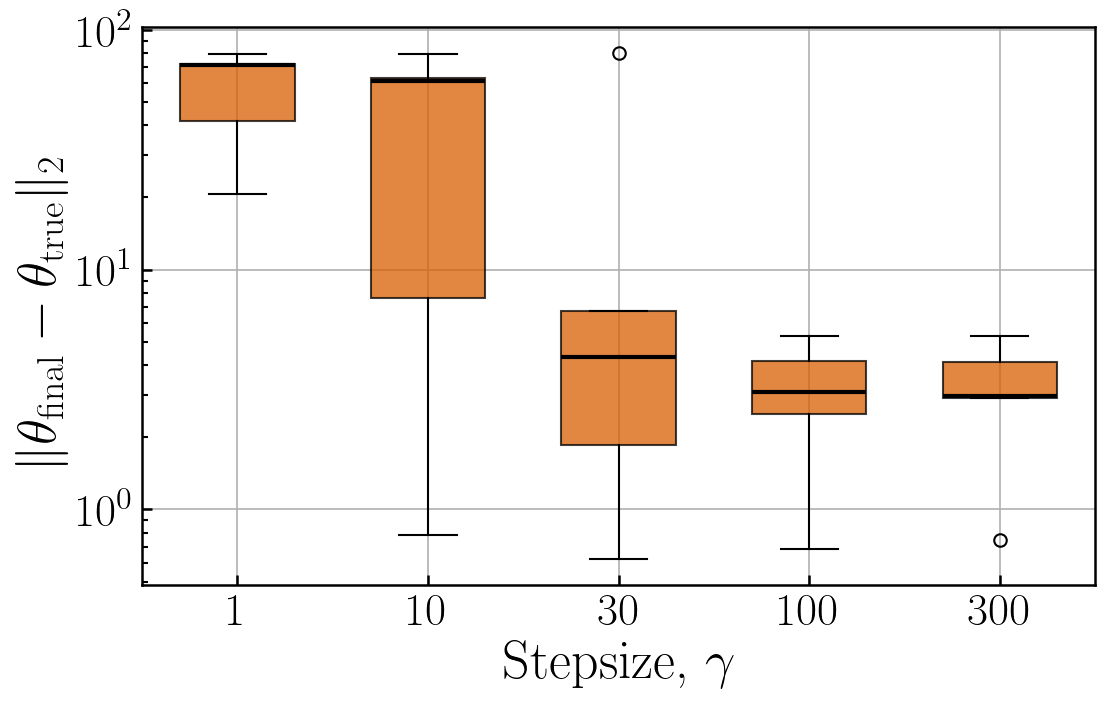

In [93]:
step_files = [path for path in lv_step_dir.glob("lotka_volterra_step_size_ablation_pgd_gamma_sweep_*.npz") if not path.name.endswith("_summary.npz")]
if step_files:
    fig = make_lv_step_boxplot(lv_step_dir, STEP_OUTPUT)
    print(f"Saved figure to {STEP_OUTPUT}")
    display(fig)
else:
    print(f"Step-size ablation figure not rendered because no files were found in {lv_step_dir}.")


Saved figure to /Users/sophiakang/Documents/GitHub/MDF_AL/figures/lv_decay_ablation.pdf


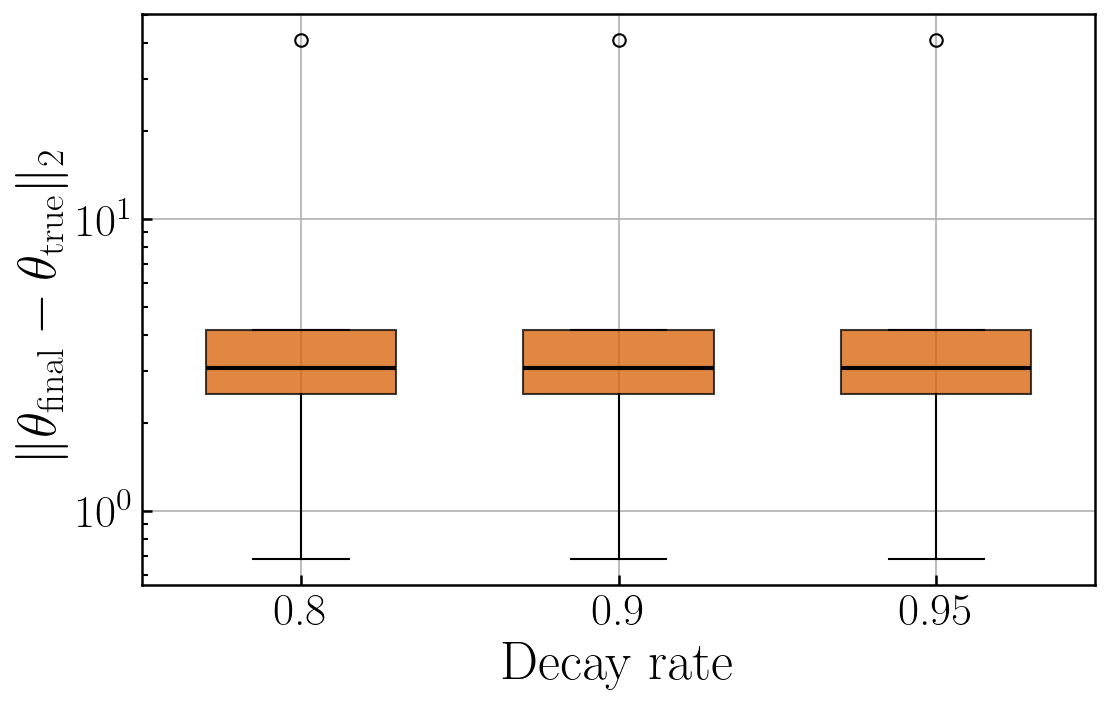

In [94]:
decay_files = [path for path in lv_decay_dir.glob("lotka_volterra_decay_ablation_pgd_decay_sweep_*.npz") if not path.name.endswith("_summary.npz")]
if decay_files:
    fig = make_lv_decay_boxplot(lv_decay_dir, DECAY_OUTPUT)
    print(f"Saved figure to {DECAY_OUTPUT}")
    display(fig)
else:
    print(f"Decay ablation figure not rendered because no files were found in {lv_decay_dir}.")


/var/folders/w6/g5h90fqj0lb6gbnsvjgzt5bw0000gn/T/ipykernel_99085/724839985.py:191: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved figure to /Users/sophiakang/Documents/GitHub/MDF_AL/figures/lv_mn_theta_error_boxplots.pdf


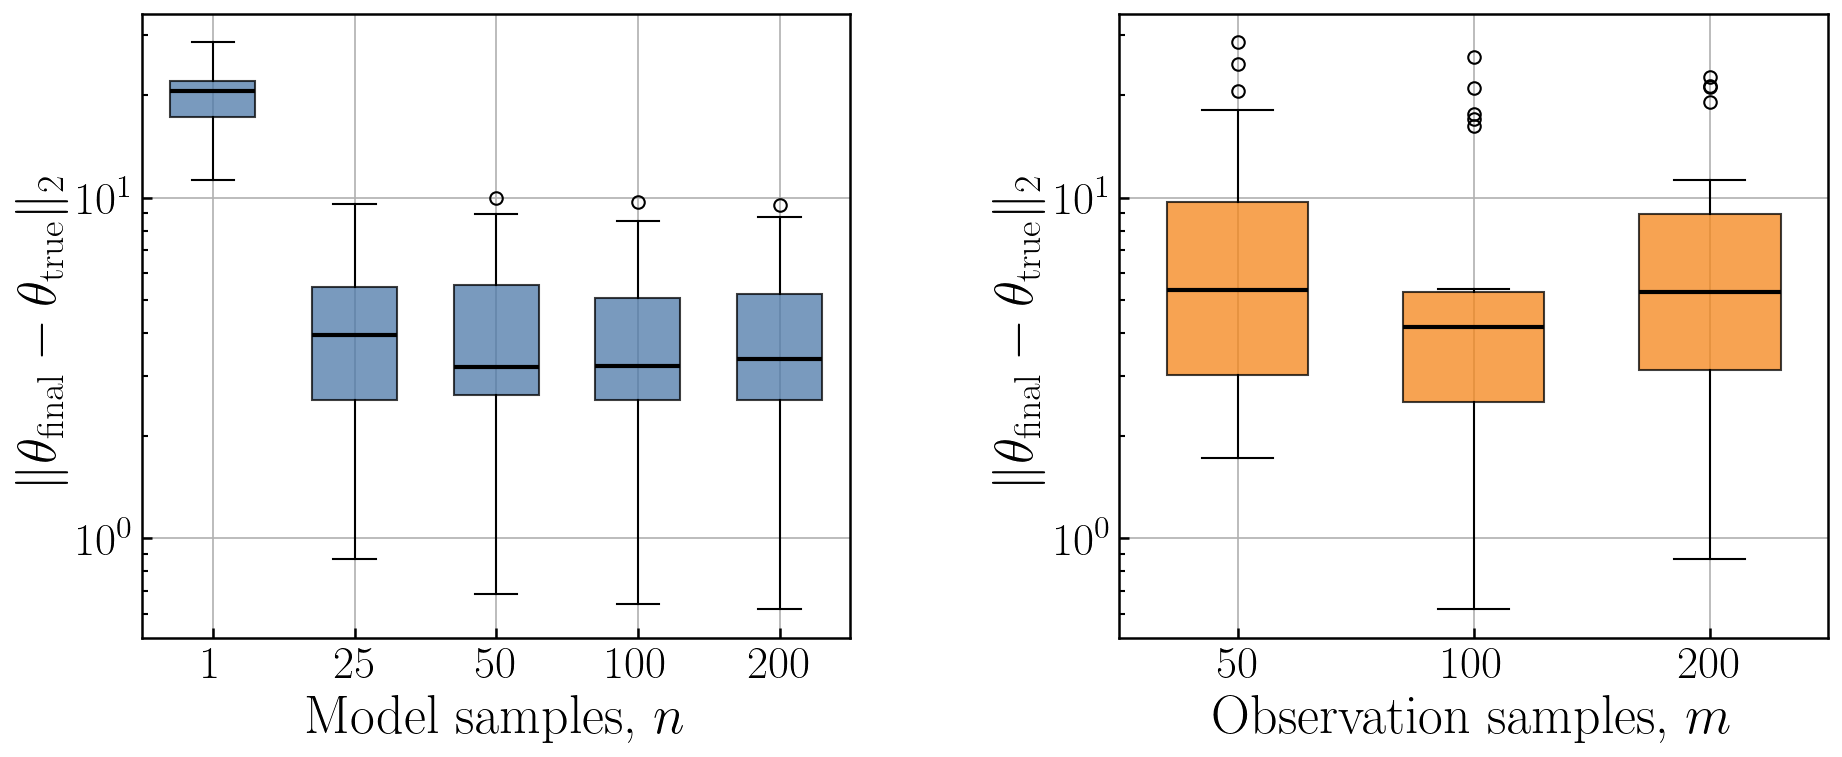

In [95]:
mn_files = list(lv_mn_dir.glob("lotka_volterra_observation_model_grid_m_*_n_*.npz"))
if mn_files:
    fig = make_lv_mn_boxplots(lv_mn_dir, MN_OUTPUT)
    print(f"Saved figure to {MN_OUTPUT}")
    display(fig)
else:
    print(f"m/n theta-error figure not rendered because no files were found in {lv_mn_dir}.")


Saved figure to /Users/sophiakang/Documents/GitHub/MDF_AL/figures/lv_cost_vs_theta_budget.pdf


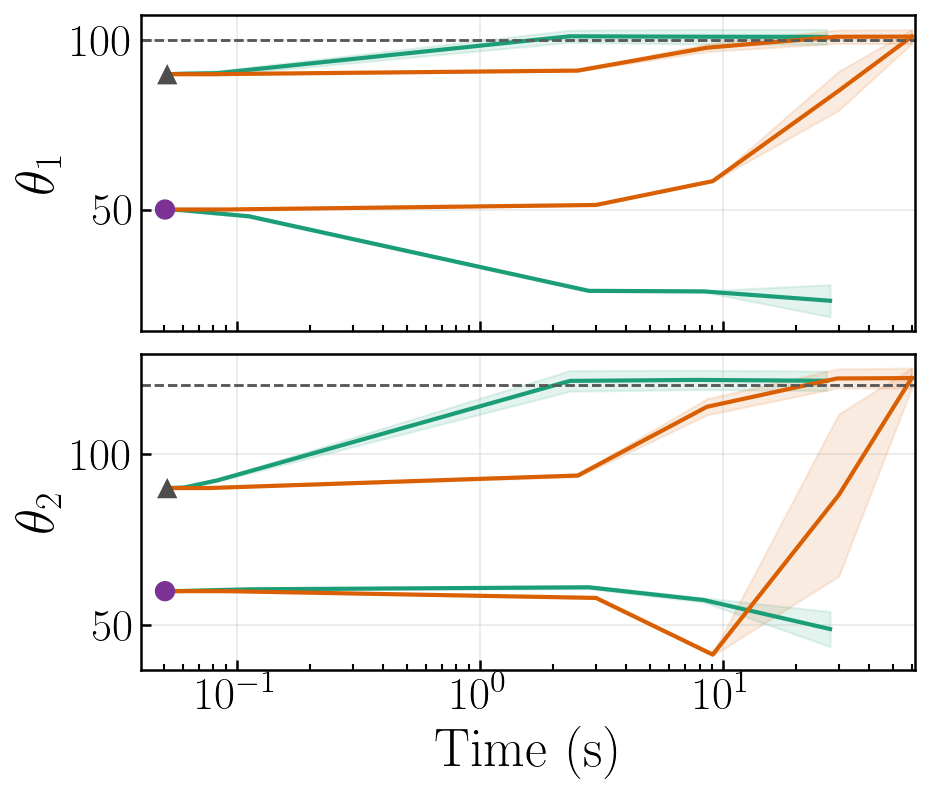

In [96]:
lv_time_budget_paths = {
    "50, 60": [
        Path("/Users/sophiakang/Documents/GitHub/MDF_AL/results/lv/lotka_volterra_results_50_60_10.npz"),
        Path("/Users/sophiakang/Documents/GitHub/MDF_AL/results/lv/lotka_volterra_results_50_60_1000.npz"),
        Path("/Users/sophiakang/Documents/GitHub/MDF_AL/results/lv/lotka_volterra_results_50_60_3000.npz"),
        Path("/Users/sophiakang/Documents/GitHub/MDF_AL/results/lv/lotka_volterra_results_50_60_10000.npz"),
        Path("/Users/sophiakang/Documents/GitHub/MDF_AL/results/lv/lotka_volterra_results_50_60_20000.npz"),
    ],
    "90, 90": [
        Path("/Users/sophiakang/Documents/GitHub/MDF_AL/results/lv/lotka_volterra_results_90_90_10.npz"),
        Path("/Users/sophiakang/Documents/GitHub/MDF_AL/results/lv/lotka_volterra_results_90_90_1000.npz"),
        Path("/Users/sophiakang/Documents/GitHub/MDF_AL/results/lv/lotka_volterra_results_90_90_3000.npz"),
        Path("/Users/sophiakang/Documents/GitHub/MDF_AL/results/lv/lotka_volterra_results_90_90_10000.npz"),
        Path("/Users/sophiakang/Documents/GitHub/MDF_AL/results/lv/lotka_volterra_results_90_90_20000.npz"),
    ],
}

def make_lv_theta_vs_time_budget_plot(path_map, output_path=None, se_scale=1.96, init_time_factor=0.85):
    init_styles = {
        "50, 60": {"marker": "o", "init_color": "#7B3294"},
        "90, 90": {"marker": "^", "init_color": "#4D4D4D"},
    }

    with plt.rc_context(LOCAL_PLOT_RC):
        fig, axes = plt.subplots(2, 1, figsize=(6.3, 5.4), dpi=150, sharex=True)
        theta_true = None
        global_max_time = 0.0
        left_limit = np.inf

        for init_label, paths in path_map.items():
            style = init_styles.get(init_label, {"marker": "o", "init_color": "#4D4D4D"})
            sgd_time = []
            pgd_time = []
            sgd_theta = []
            pgd_theta = []
            theta0 = None
            sgd_theta_se = []
            pgd_theta_se = []

            for npz_path in paths:
                data = _load_npz_dict(npz_path)
                theta_true = np.asarray(data["theta_true"], dtype=float)
                theta0 = np.asarray(data["theta0"], dtype=float)
                sgd_time.append(float(np.asarray(data["sgd_elapsed_mean"], dtype=float)))
                pgd_time.append(float(np.asarray(data["pgd_elapsed_mean"], dtype=float)))
                sgd_theta.append(np.asarray(data["sgd_theta_mean"], dtype=float)[:2])
                pgd_theta.append(np.asarray(data["pgd_theta_mean"], dtype=float)[:2])
                sgd_theta_se.append(np.asarray(data["sgd_theta_se"], dtype=float)[:2])
                pgd_theta_se.append(np.asarray(data["pgd_theta_se"], dtype=float)[:2])

            sgd_time = np.asarray(sgd_time, dtype=float)
            pgd_time = np.asarray(pgd_time, dtype=float)
            sgd_theta = np.asarray(sgd_theta, dtype=float)
            pgd_theta = np.asarray(pgd_theta, dtype=float)
            sgd_theta_se = np.asarray(sgd_theta_se, dtype=float)
            pgd_theta_se = np.asarray(pgd_theta_se, dtype=float)

            global_max_time = max(global_max_time, float(np.max(sgd_time)), float(np.max(pgd_time)))
            sgd_order = np.argsort(sgd_time)
            pgd_order = np.argsort(pgd_time)
            init_time = init_time_factor * min(float(np.min(sgd_time)), float(np.min(pgd_time)))
            left_limit = min(left_limit, 0.8 * init_time)

            for param_idx, ax in enumerate(axes):
                sgd_plot_time = np.concatenate(([init_time], sgd_time[sgd_order]))
                sgd_plot_theta = np.concatenate(([theta0[param_idx]], sgd_theta[sgd_order, param_idx]))
                pgd_plot_time = np.concatenate(([init_time], pgd_time[pgd_order]))
                pgd_plot_theta = np.concatenate(([theta0[param_idx]], pgd_theta[pgd_order, param_idx]))

                ax.plot(
                    sgd_plot_time,
                    sgd_plot_theta,
                    color=COLORS["gd"],
                    linewidth=2.0,
                    marker=None,
                )
                ax.fill_between(
                    sgd_time[sgd_order],
                    sgd_theta[sgd_order, param_idx] - se_scale * sgd_theta_se[sgd_order, param_idx],
                    sgd_theta[sgd_order, param_idx] + se_scale * sgd_theta_se[sgd_order, param_idx],
                    color=COLORS["gd"],
                    alpha=0.12,
                )
                ax.plot(
                    pgd_plot_time,
                    pgd_plot_theta,
                    color=COLORS["pgd"],
                    linewidth=2.0,
                    marker=None,
                )
                ax.fill_between(
                    pgd_time[pgd_order],
                    pgd_theta[pgd_order, param_idx] - se_scale * pgd_theta_se[pgd_order, param_idx],
                    pgd_theta[pgd_order, param_idx] + se_scale * pgd_theta_se[pgd_order, param_idx],
                    color=COLORS["pgd"],
                    alpha=0.12,
                )
                ax.scatter(
                    init_time,
                    theta0[param_idx],
                    color=style["init_color"],
                    marker=style["marker"],
                    edgecolors="none",
                    linewidths=0.0,
                    s=95,
                    zorder=6,
                )
                ax.axhline(float(theta_true[param_idx]), color="0.35", linestyle="--", linewidth=1.2)
                ax.set_ylabel(rf"$\theta_{param_idx + 1}$")
                ax.grid(True, which="major", alpha=0.28, linewidth=0.8)

        for ax in axes:
            ax.set_xscale("log")
            ax.set_xlim(left_limit, global_max_time * 1.03)

        axes[-1].set_xlabel("Time (s)")
        fig.tight_layout()
        return _save_figure(fig, output_path)


fig = make_lv_theta_vs_time_budget_plot(
    lv_time_budget_paths,
    output_path=FIGURES_DIR / "lv_cost_vs_theta_budget.pdf",
)
print(f"Saved figure to {FIGURES_DIR / 'lv_cost_vs_theta_budget.pdf'}")
display(fig)


Saved figure to /Users/sophiakang/Documents/GitHub/MDF_AL/figures/lv_cost_vs_theta_corruption.pdf


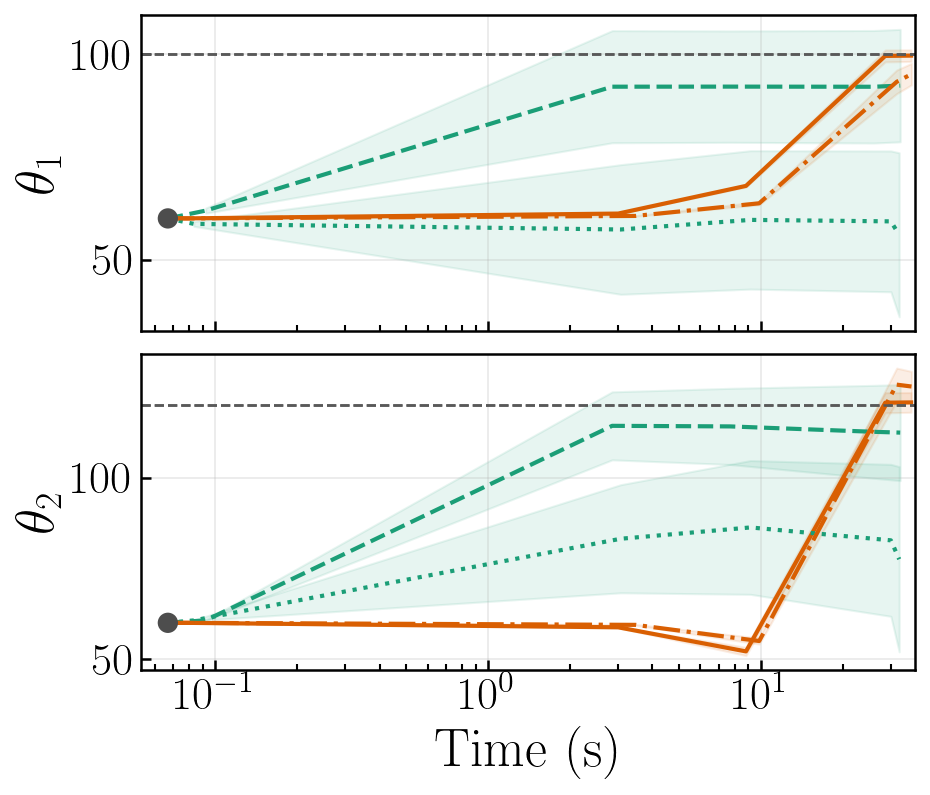

In [97]:
lv_corruption_time_paths = {
    "c15": [
        Path("/Users/sophiakang/Documents/GitHub/MDF_AL/results/lv/lotka_volterra_results_60_60_c15_10.npz"),
        Path("/Users/sophiakang/Documents/GitHub/MDF_AL/results/lv/lotka_volterra_results_60_60_c15_1000.npz"),
        Path("/Users/sophiakang/Documents/GitHub/MDF_AL/results/lv/lotka_volterra_results_60_60_c15_3000.npz"),
        Path("/Users/sophiakang/Documents/GitHub/MDF_AL/results/lv/lotka_volterra_results_60_60_c15_10000.npz"),
        Path("/Users/sophiakang/Documents/GitHub/MDF_AL/results/lv/lotka_volterra_results_60_60_c15_12000.npz"),
    ],
    "c35": [
        Path("/Users/sophiakang/Documents/GitHub/MDF_AL/results/lv/lotka_volterra_results_60_60_c35_10.npz"),
        Path("/Users/sophiakang/Documents/GitHub/MDF_AL/results/lv/lotka_volterra_results_60_60_c35_1000.npz"),
        Path("/Users/sophiakang/Documents/GitHub/MDF_AL/results/lv/lotka_volterra_results_60_60_c35_3000.npz"),
        Path("/Users/sophiakang/Documents/GitHub/MDF_AL/results/lv/lotka_volterra_results_60_60_c35_10000.npz"),
        Path("/Users/sophiakang/Documents/GitHub/MDF_AL/results/lv/lotka_volterra_results_60_60_c35_12000.npz"),
    ],
}

def make_lv_corruption_theta_vs_time_plot(path_map, output_path=None, se_scale=1.96, init_time_factor=0.85):
    line_styles = {"c15": ("--", "-"), "c35": (":", "-.")}

    with plt.rc_context(LOCAL_PLOT_RC):
        fig, axes = plt.subplots(2, 1, figsize=(6.3, 5.4), dpi=150, sharex=True)
        theta_true = None
        theta0_shared = None
        shared_init_time = None
        global_max_time = 0.0
        left_limit = np.inf

        for label, paths in path_map.items():
            sgd_time = []
            pgd_time = []
            sgd_theta = []
            pgd_theta = []
            sgd_theta_se = []
            pgd_theta_se = []
            theta0 = None

            for npz_path in paths:
                data = _load_npz_dict(npz_path)
                theta_true = np.asarray(data["theta_true"], dtype=float)
                theta0 = np.asarray(data["theta0"], dtype=float)
                theta0_shared = theta0
                sgd_time.append(float(np.asarray(data["sgd_elapsed_mean"], dtype=float)))
                pgd_time.append(float(np.asarray(data["pgd_elapsed_mean"], dtype=float)))
                sgd_theta.append(np.asarray(data["sgd_theta_mean"], dtype=float)[:2])
                pgd_theta.append(np.asarray(data["pgd_theta_mean"], dtype=float)[:2])
                sgd_theta_se.append(np.asarray(data["sgd_theta_se"], dtype=float)[:2])
                pgd_theta_se.append(np.asarray(data["pgd_theta_se"], dtype=float)[:2])

            sgd_time = np.asarray(sgd_time, dtype=float)
            pgd_time = np.asarray(pgd_time, dtype=float)
            sgd_theta = np.asarray(sgd_theta, dtype=float)
            pgd_theta = np.asarray(pgd_theta, dtype=float)
            sgd_theta_se = np.asarray(sgd_theta_se, dtype=float)
            pgd_theta_se = np.asarray(pgd_theta_se, dtype=float)
            if len(sgd_time) == 0 or len(pgd_time) == 0:
                continue

            global_max_time = max(global_max_time, float(np.max(sgd_time)), float(np.max(pgd_time)))
            sgd_order = np.argsort(sgd_time)
            pgd_order = np.argsort(pgd_time)
            init_time = init_time_factor * min(float(np.min(sgd_time)), float(np.min(pgd_time)))
            left_limit = min(left_limit, 0.8 * init_time)
            if shared_init_time is None:
                shared_init_time = init_time
            line_init_time = shared_init_time
            sgd_ls, pgd_ls = line_styles.get(label, ("--", "-"))

            for param_idx, ax in enumerate(axes):
                sgd_plot_time = np.concatenate(([line_init_time], sgd_time[sgd_order]))
                sgd_plot_theta = np.concatenate(([theta0[param_idx]], sgd_theta[sgd_order, param_idx]))
                pgd_plot_time = np.concatenate(([line_init_time], pgd_time[pgd_order]))
                pgd_plot_theta = np.concatenate(([theta0[param_idx]], pgd_theta[pgd_order, param_idx]))

                ax.plot(
                    sgd_plot_time,
                    sgd_plot_theta,
                    color=COLORS["gd"],
                    linestyle=sgd_ls,
                    linewidth=2.0,
                    marker=None,
                )
                ax.fill_between(
                    sgd_time[sgd_order],
                    sgd_theta[sgd_order, param_idx] - se_scale * sgd_theta_se[sgd_order, param_idx],
                    sgd_theta[sgd_order, param_idx] + se_scale * sgd_theta_se[sgd_order, param_idx],
                    color=COLORS["gd"],
                    alpha=0.10,
                )
                ax.plot(
                    pgd_plot_time,
                    pgd_plot_theta,
                    color=COLORS["pgd"],
                    linestyle=pgd_ls,
                    linewidth=2.0,
                    marker=None,
                )
                ax.fill_between(
                    pgd_time[pgd_order],
                    pgd_theta[pgd_order, param_idx] - se_scale * pgd_theta_se[pgd_order, param_idx],
                    pgd_theta[pgd_order, param_idx] + se_scale * pgd_theta_se[pgd_order, param_idx],
                    color=COLORS["pgd"],
                    alpha=0.10,
                )
                ax.axhline(float(theta_true[param_idx]), color="0.35", linestyle="--", linewidth=1.2)
                ax.set_ylabel(rf"$\theta_{param_idx + 1}$")
                ax.grid(True, which="major", alpha=0.28, linewidth=0.8)

        if theta0_shared is not None and shared_init_time is not None:
            for param_idx, ax in enumerate(axes):
                ax.scatter(
                    shared_init_time,
                    theta0_shared[param_idx],
                    color="#4D4D4D",
                    marker="o",
                    edgecolors="none",
                    linewidths=0.0,
                    s=95,
                    zorder=6,
                )

        for ax in axes:
            ax.set_xscale("log")
            ax.set_xlim(left_limit, global_max_time * 1.03)

        axes[-1].set_xlabel("Time (s)")
        fig.tight_layout()
        return _save_figure(fig, output_path)


fig = make_lv_corruption_theta_vs_time_plot(
    lv_corruption_time_paths,
    output_path=FIGURES_DIR / "lv_cost_vs_theta_corruption.pdf",
)
print(f"Saved figure to {FIGURES_DIR / 'lv_cost_vs_theta_corruption.pdf'}")
display(fig)


In [ ]:
lv_compare_output = FIGURES_DIR / "lv_cross_method_comparison.pdf"
if lv_compare_npz.exists():
    try:
        fig = make_lv_cross_method_comparison(lv_compare_npz, lv_compare_output)
        print(f"Saved figure to {lv_compare_output}")
        display(fig)
    except KeyError as exc:
        print(f"Cross-method comparison not rendered: {exc}")
        print("This file has the flags but does not include saved adaptive_sgd/fixed_pgd histories. Regenerate the .npz with the updated code to plot this comparison.")
else:
    print(f"Cross-method comparison not rendered because {lv_compare_npz} is missing.")


Saved figure to /Users/sophiakang/Documents/GitHub/MDF_AL/figures/lv_lengthscale_pair_ablation.pdf


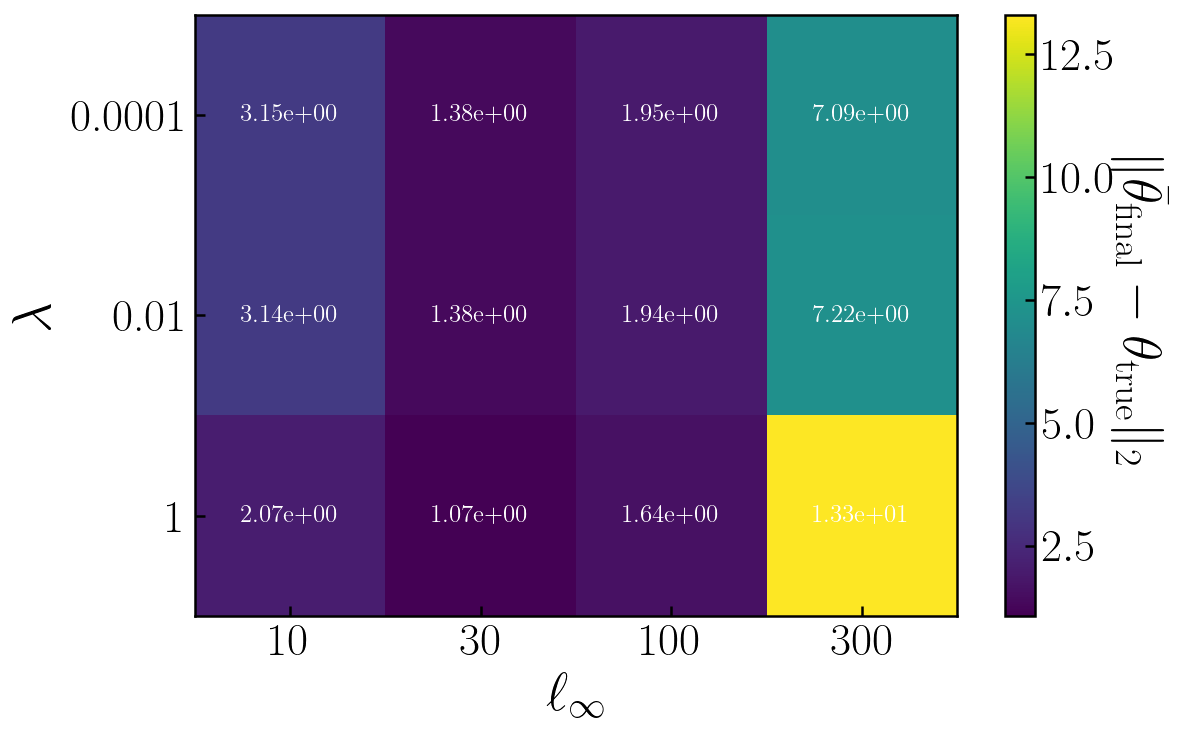

In [98]:
if lv_lengthscale_summary.exists():
    fig = make_lv_lengthscale_ridge_heatmap(lv_lengthscale_summary, LENGTHSCALE_OUTPUT)
    print(f"Saved figure to {LENGTHSCALE_OUTPUT}")
    display(fig)
else:
    print(f"Lengthscale/ridge figure not rendered because {lv_lengthscale_summary} is missing.")
